# Titulo: Autocorrelación espacial global.
## Diplomado: Geoestadística y análisis espacial
## SciData
## Instructor: Alexis Adonai Morales Alberto


In [52]:
# Modulos

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import drive
from libpysal.weights import Queen
from libpysal.weights import Rook
from shapely.geometry import LineString
from libpysal.weights import KNN
from libpysal.weights import DistanceBand
from pysal.viz import splot
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import plot_moran
from splot import esda as esdaplot



## Mapa temático para identificar el fenómeno

In [2]:
# Configuración de google drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Ruta completa del archivo

ruta_mapa = '/content/drive/MyDrive/SciData/GEOAES_25/Mapas/México_ent_22/00ent'
ruta_data = '/content/drive/MyDrive/SciData/GEOAES_25/Bases/Pobreza_rel_2024.csv'

In [4]:
# Cargar mapa

Mapa = gpd.read_file(ruta_mapa + '.shp')
Mapa.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [5]:
# Cargar datos de pobreza 2024

Data = pd.read_csv(ruta_data)

Data.head(1)

,CVE_ENT,ENTIDAD,Pobreza
0,1,Aguascalientes,17.068482


In [6]:
# Verificar columnas

Mapa['CVE_ENT'] = pd.to_numeric(Mapa['CVE_ENT'], errors = 'coerce')

Mapa[['CVE_ENT', 'NOMGEO']].dtypes

,0
CVE_ENT,int64
NOMGEO,object


In [7]:
Mapa.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [8]:
Data[['CVE_ENT', 'ENTIDAD']].dtypes

,0
CVE_ENT,int64
ENTIDAD,object


In [9]:
# Combinar datos con el mapa

Mapa = Mapa.merge(
    Data,
    left_on= ["CVE_ENT","NOMGEO"],
    right_on=["CVE_ENT","ENTIDAD"],
    how = 'left'
)

In [10]:
Mapa.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [11]:
Mapa.dtypes

,0
CVEGEO,object
CVE_ENT,int64
NOMGEO,object
geometry,geometry
ENTIDAD,object
Pobreza,float64


In [12]:
Mapa = Mapa.rename(columns={'Pobreza ': 'Pobreza'}) # Aportación de Jorge Calvillo

<Figure size 7500x6000 with 0 Axes>

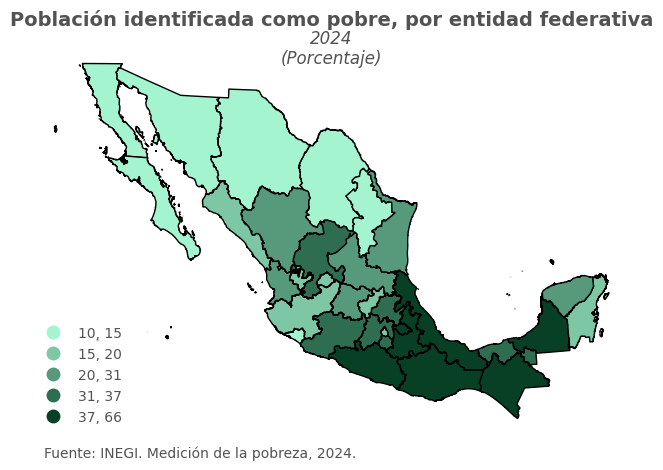

In [13]:
# Definición de paleta

from matplotlib.colors import ListedColormap

Colores = ["#A4F4CF", "#7DC7A5", "#569A7B", "#2F6D51", "#084026"]

cmap_manual = ListedColormap(Colores)

# Mapa temático con variable continua

plt.figure(figsize=(15,12), dpi = 500)
Mapa.plot(
    column = 'Pobreza',
    scheme = 'Quantiles',
    k = 5,
    legend = True,
    cmap = cmap_manual,
    legend_kwds = {'loc': 'lower left',
                   'fmt': "{:.0f}"},
    edgecolor = "black"
)
plt.axis('off') # Quita los ejes
plt.figtext(0.5, 0.95, "Población identificada como pobre, por entidad federativa",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.5, 0.87, "2024\n(Porcentaje)",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: INEGI. Medición de la pobreza, 2024.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
leg = ax.get_legend()
for text in leg.get_texts():
  text.set_color('#525252')
if leg is not None:
  leg.get_frame().set_linewidth(0)
  leg.get_frame().set_edgecolor("none")
plt.grid(False)
plt.tight_layout(rect = [0,0.05,1,0.95])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Mapa_pobreza.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')

## Matrices de pesos espaciales


1. Contiguedad de Reina



In [14]:
# Cálculo de matriz

W_queen = Queen.from_dataframe(Mapa, ids = "CVE_ENT")

# Normalizar filas

W_queen.transform = 'r'

2. Métodos de vcinos (4 vecinos)

In [15]:
## Cálculo de la matriz con 4 vecinos por área

knn4 = KNN.from_dataframe(Mapa, k = 4, ids = "CVE_ENT")

# Normalizar filas

knn4.transform = 'r'

3. Método de distancia inversa

In [16]:
# Cálculo de matriz inversa de la distancia

W_D_inv = DistanceBand.from_dataframe(
    Mapa,
    threshold= 9000000,
    binary = False,
    p = 2,
    alpha = -2.0,
    ids = "CVE_ENT"
)

W_D_inv.transform = "r"

## Cálcular el rezago espacial

In [17]:
Mapa['lag_pobreza_WQ'] = weights.spatial_lag.lag_spatial(W_queen, Mapa['Pobreza'])
Mapa['lag_pobreza_k4'] = weights.spatial_lag.lag_spatial(knn4, Mapa['Pobreza'])
Mapa['lag_pobreza_Inv'] = weights.spatial_lag.lag_spatial(W_D_inv, Mapa['Pobreza'])

## Estadístico de Moran Global

1. Mediante matriz de peso espacial de reina

In [18]:
# Estadístico

Moran_WQ = esda.moran.Moran(Mapa['Pobreza'], W_queen)

In [19]:
print(f"El valor del índice es de: {Moran_WQ.I:.2f}")
print(f"El valor estadístico Z de Moran es de: {Moran_WQ.z_norm:.2f}")
print(f"El valor de probabilidad del estadístico Z de Moran es de: {Moran_WQ.p_norm:.2f}")

El valor del índice es de: 0.53
El valor estadístico Z de Moran es de: 4.51
El valor de probabilidad del estadístico Z de Moran es de: 0.00


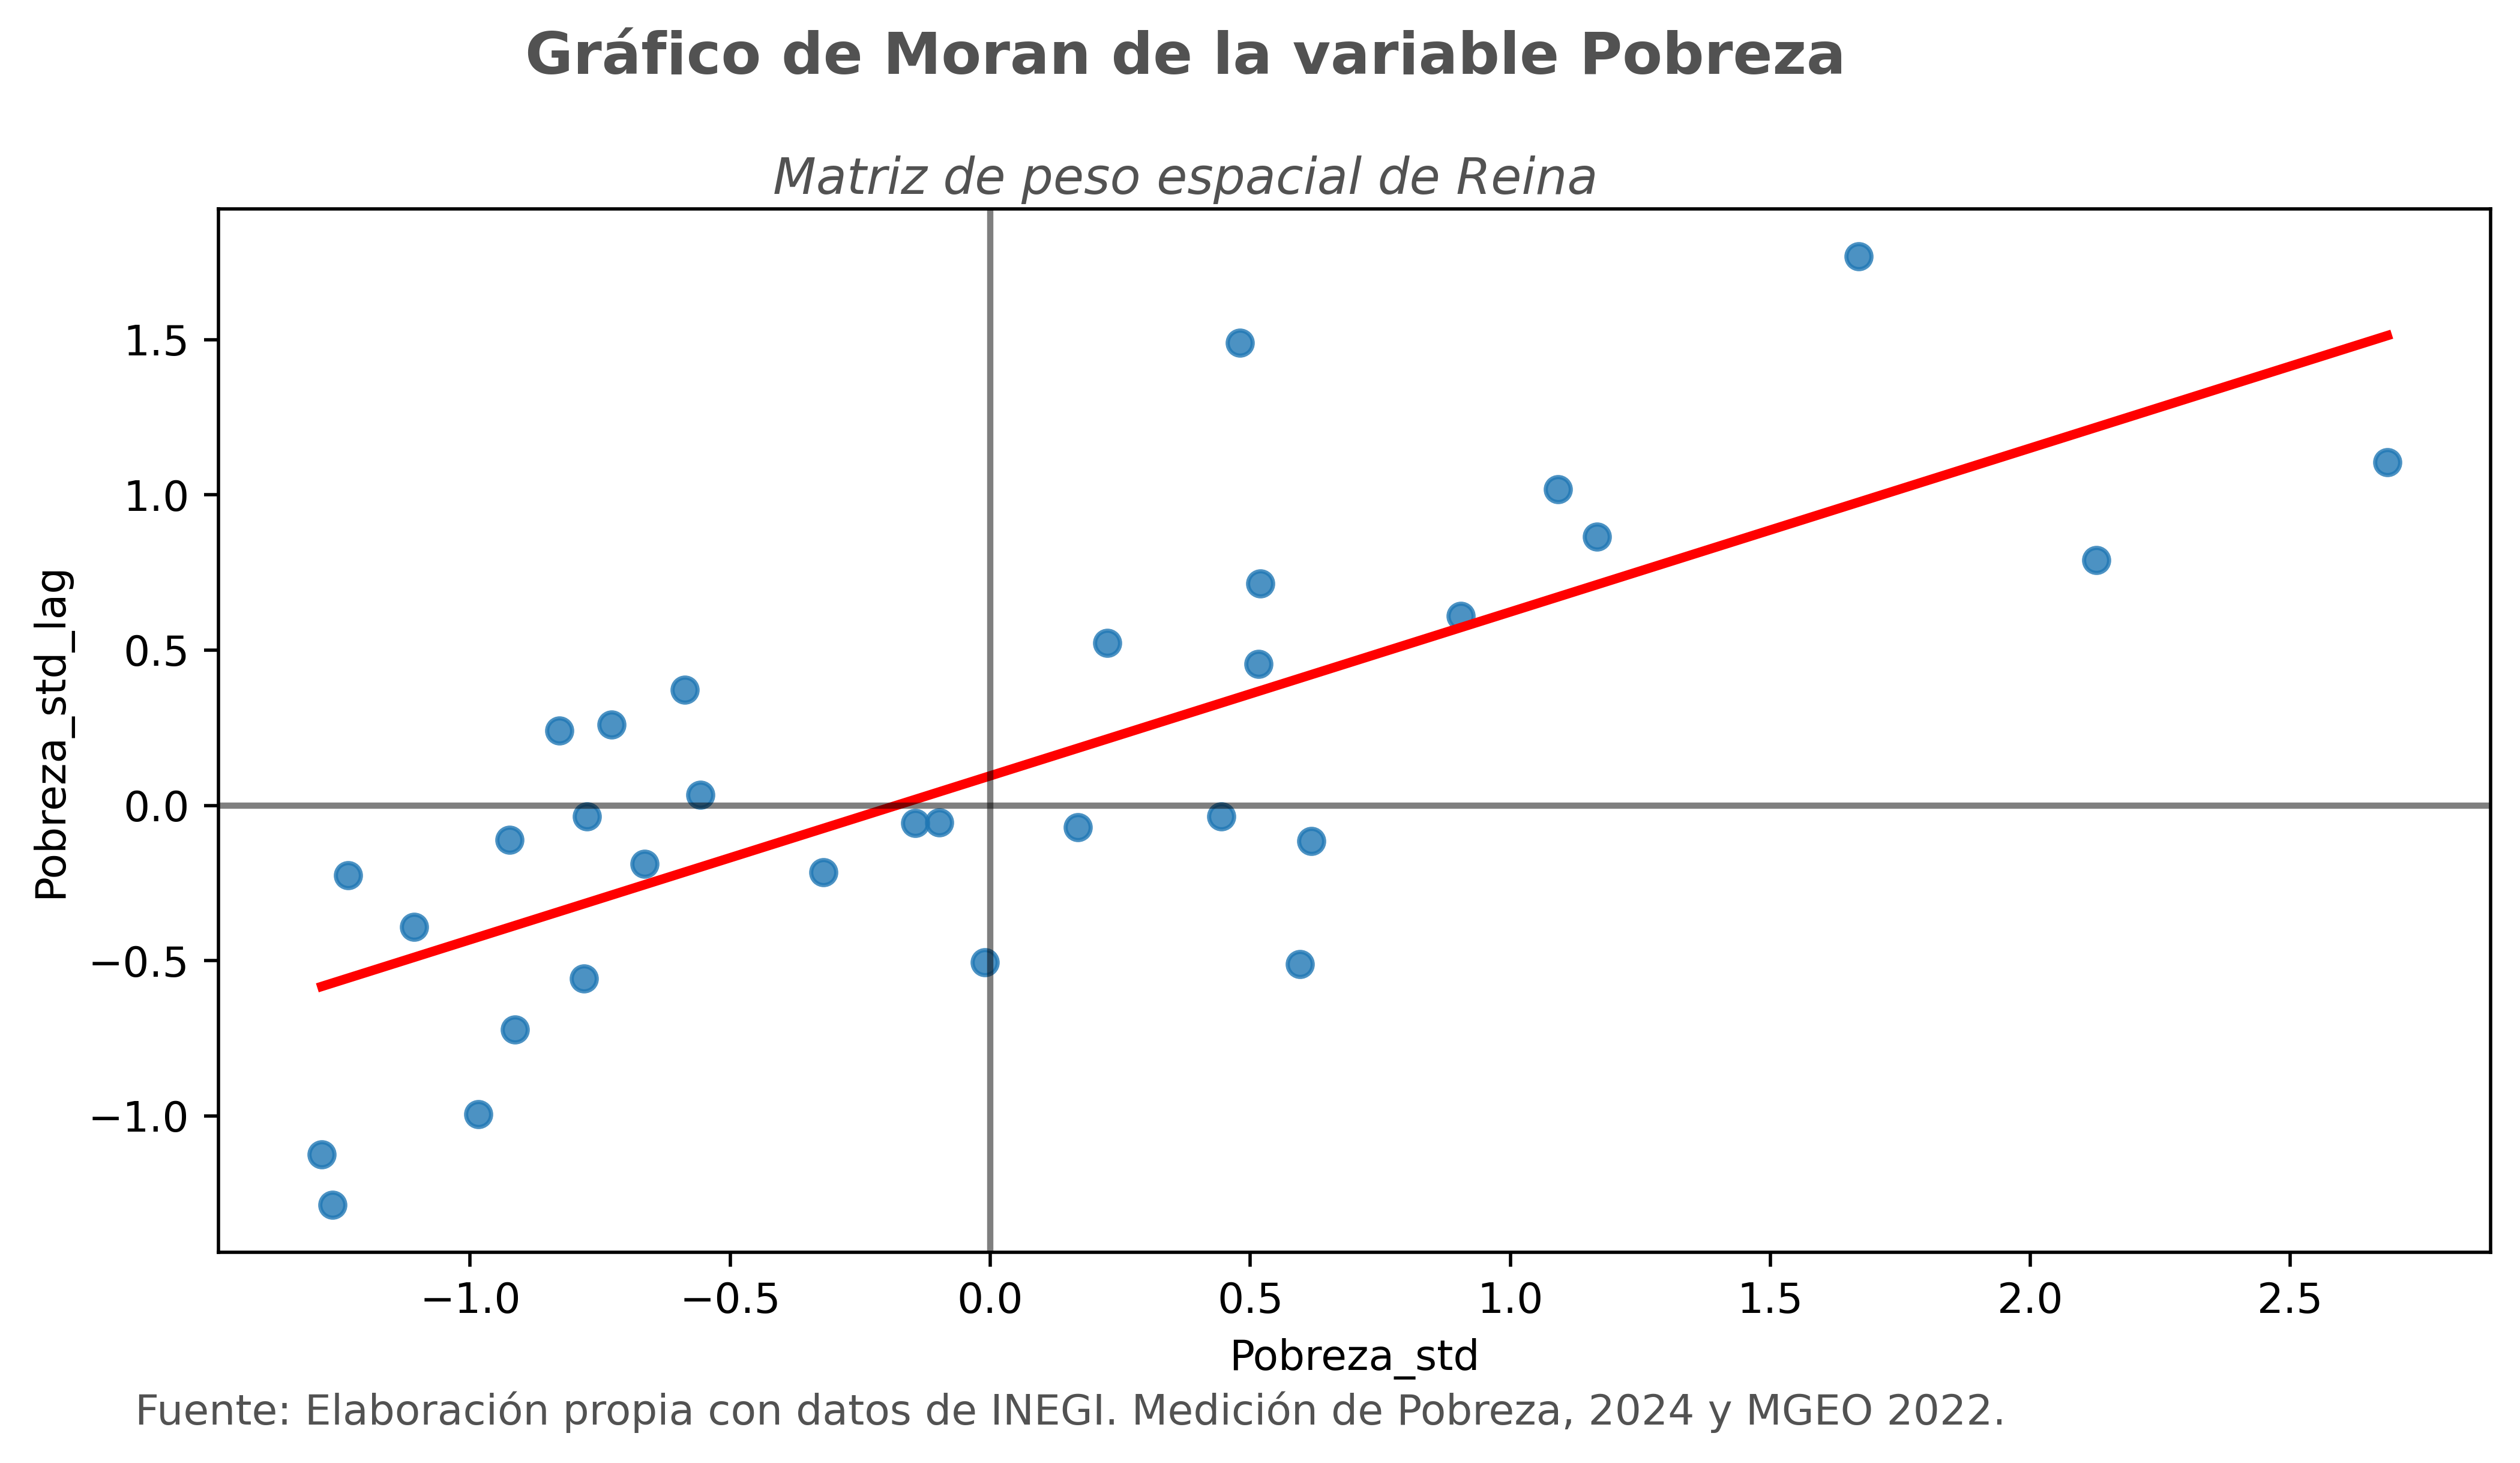

In [20]:
# Gráfico

Mapa['Pobreza_std'] = (Mapa['Pobreza']-Mapa['Pobreza'].mean())/np.std(Mapa['Pobreza'])
Mapa['Pobreza_std_lag'] = weights.spatial_lag.lag_spatial(W_queen, Mapa['Pobreza_std'])

f, ax = plt.subplots(1, figsize = (10,5), dpi = 500)
sns.regplot(
    x = 'Pobreza_std',
    y = 'Pobreza_std_lag',
    ci = None,
    data = Mapa,
    line_kws = {'color': 'r'}
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
plt.figtext(0.4, 0.95, "Gráfico de Moran de la variable Pobreza",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Matriz de peso espacial de Reina",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos de INEGI. Medición de Pobreza, 2024 y MGEO 2022.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.89])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Moran_Reina.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')



2. Con método de 4 vecinos

In [21]:
# Estadístico

Moran_Wknn4 = esda.moran.Moran(Mapa['Pobreza'], knn4)

In [22]:
print(f"El valor del índice es de: {Moran_Wknn4.I:.2f}")
print(f"El valor estadístico Z de Moran es de: {Moran_Wknn4.z_norm:.2f}")
print(f"El valor de probabilidad del estadístico Z de Moran es de: {Moran_Wknn4.p_norm:.2f}")

El valor del índice es de: 0.41
El valor estadístico Z de Moran es de: 4.21
El valor de probabilidad del estadístico Z de Moran es de: 0.00


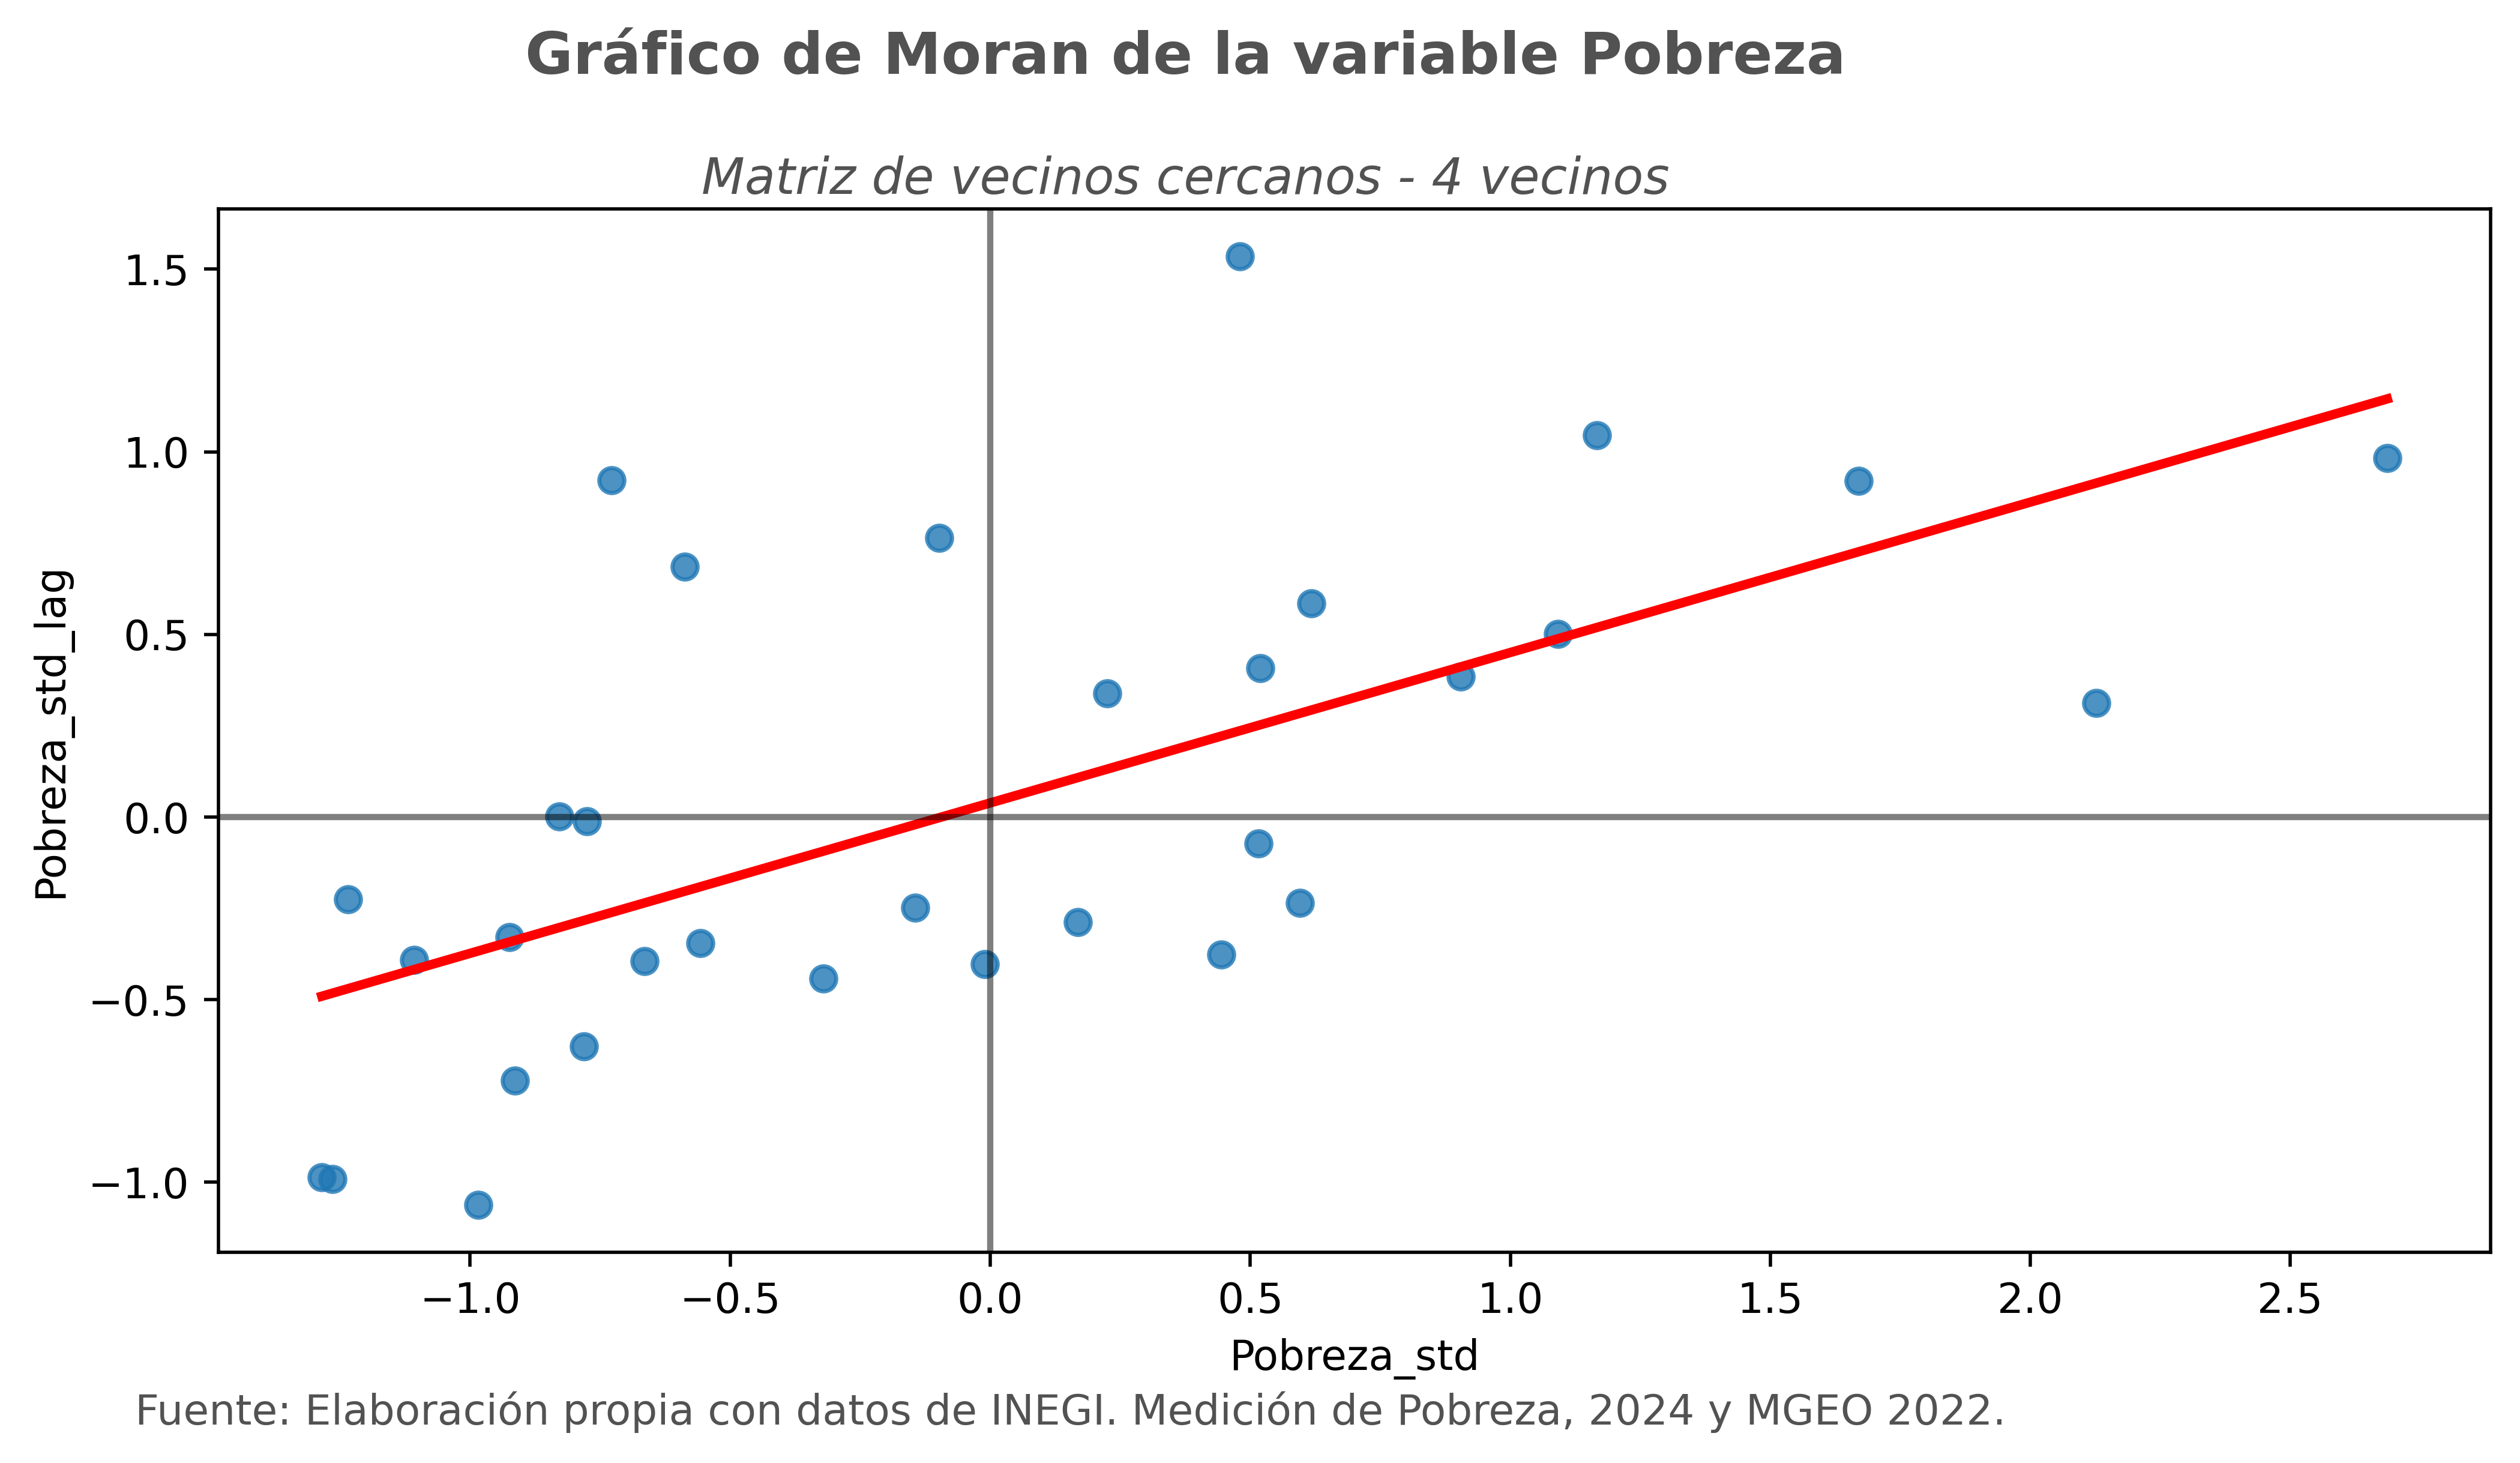

In [23]:
# Gráfico

Mapa['Pobreza_std'] = (Mapa['Pobreza']-Mapa['Pobreza'].mean())/np.std(Mapa['Pobreza'])
Mapa['Pobreza_std_lag'] = weights.spatial_lag.lag_spatial(knn4, Mapa['Pobreza_std'])

f, ax = plt.subplots(1, figsize = (10,5), dpi = 500)
sns.regplot(
    x = 'Pobreza_std',
    y = 'Pobreza_std_lag',
    ci = None,
    data = Mapa,
    line_kws = {'color': 'r'}
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
plt.figtext(0.4, 0.95, "Gráfico de Moran de la variable Pobreza",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Matriz de vecinos cercanos - 4 vecinos",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos de INEGI. Medición de Pobreza, 2024 y MGEO 2022.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.89])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Moran_knn4.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')

3. Con método de distancia a la inversa

In [24]:
# Estadístico

Moran_W_inv = esda.moran.Moran(Mapa['Pobreza'], W_D_inv)

In [25]:
print(f"El valor del índice es de: {Moran_W_inv.I:.2f}")
print(f"El valor estadístico Z de Moran es de: {Moran_W_inv.z_norm:.2f}")
print(f"El valor de probabilidad del estadístico Z de Moran es de: {Moran_W_inv.p_norm:.2f}")

El valor del índice es de: 0.27
El valor estadístico Z de Moran es de: 3.87
El valor de probabilidad del estadístico Z de Moran es de: 0.00


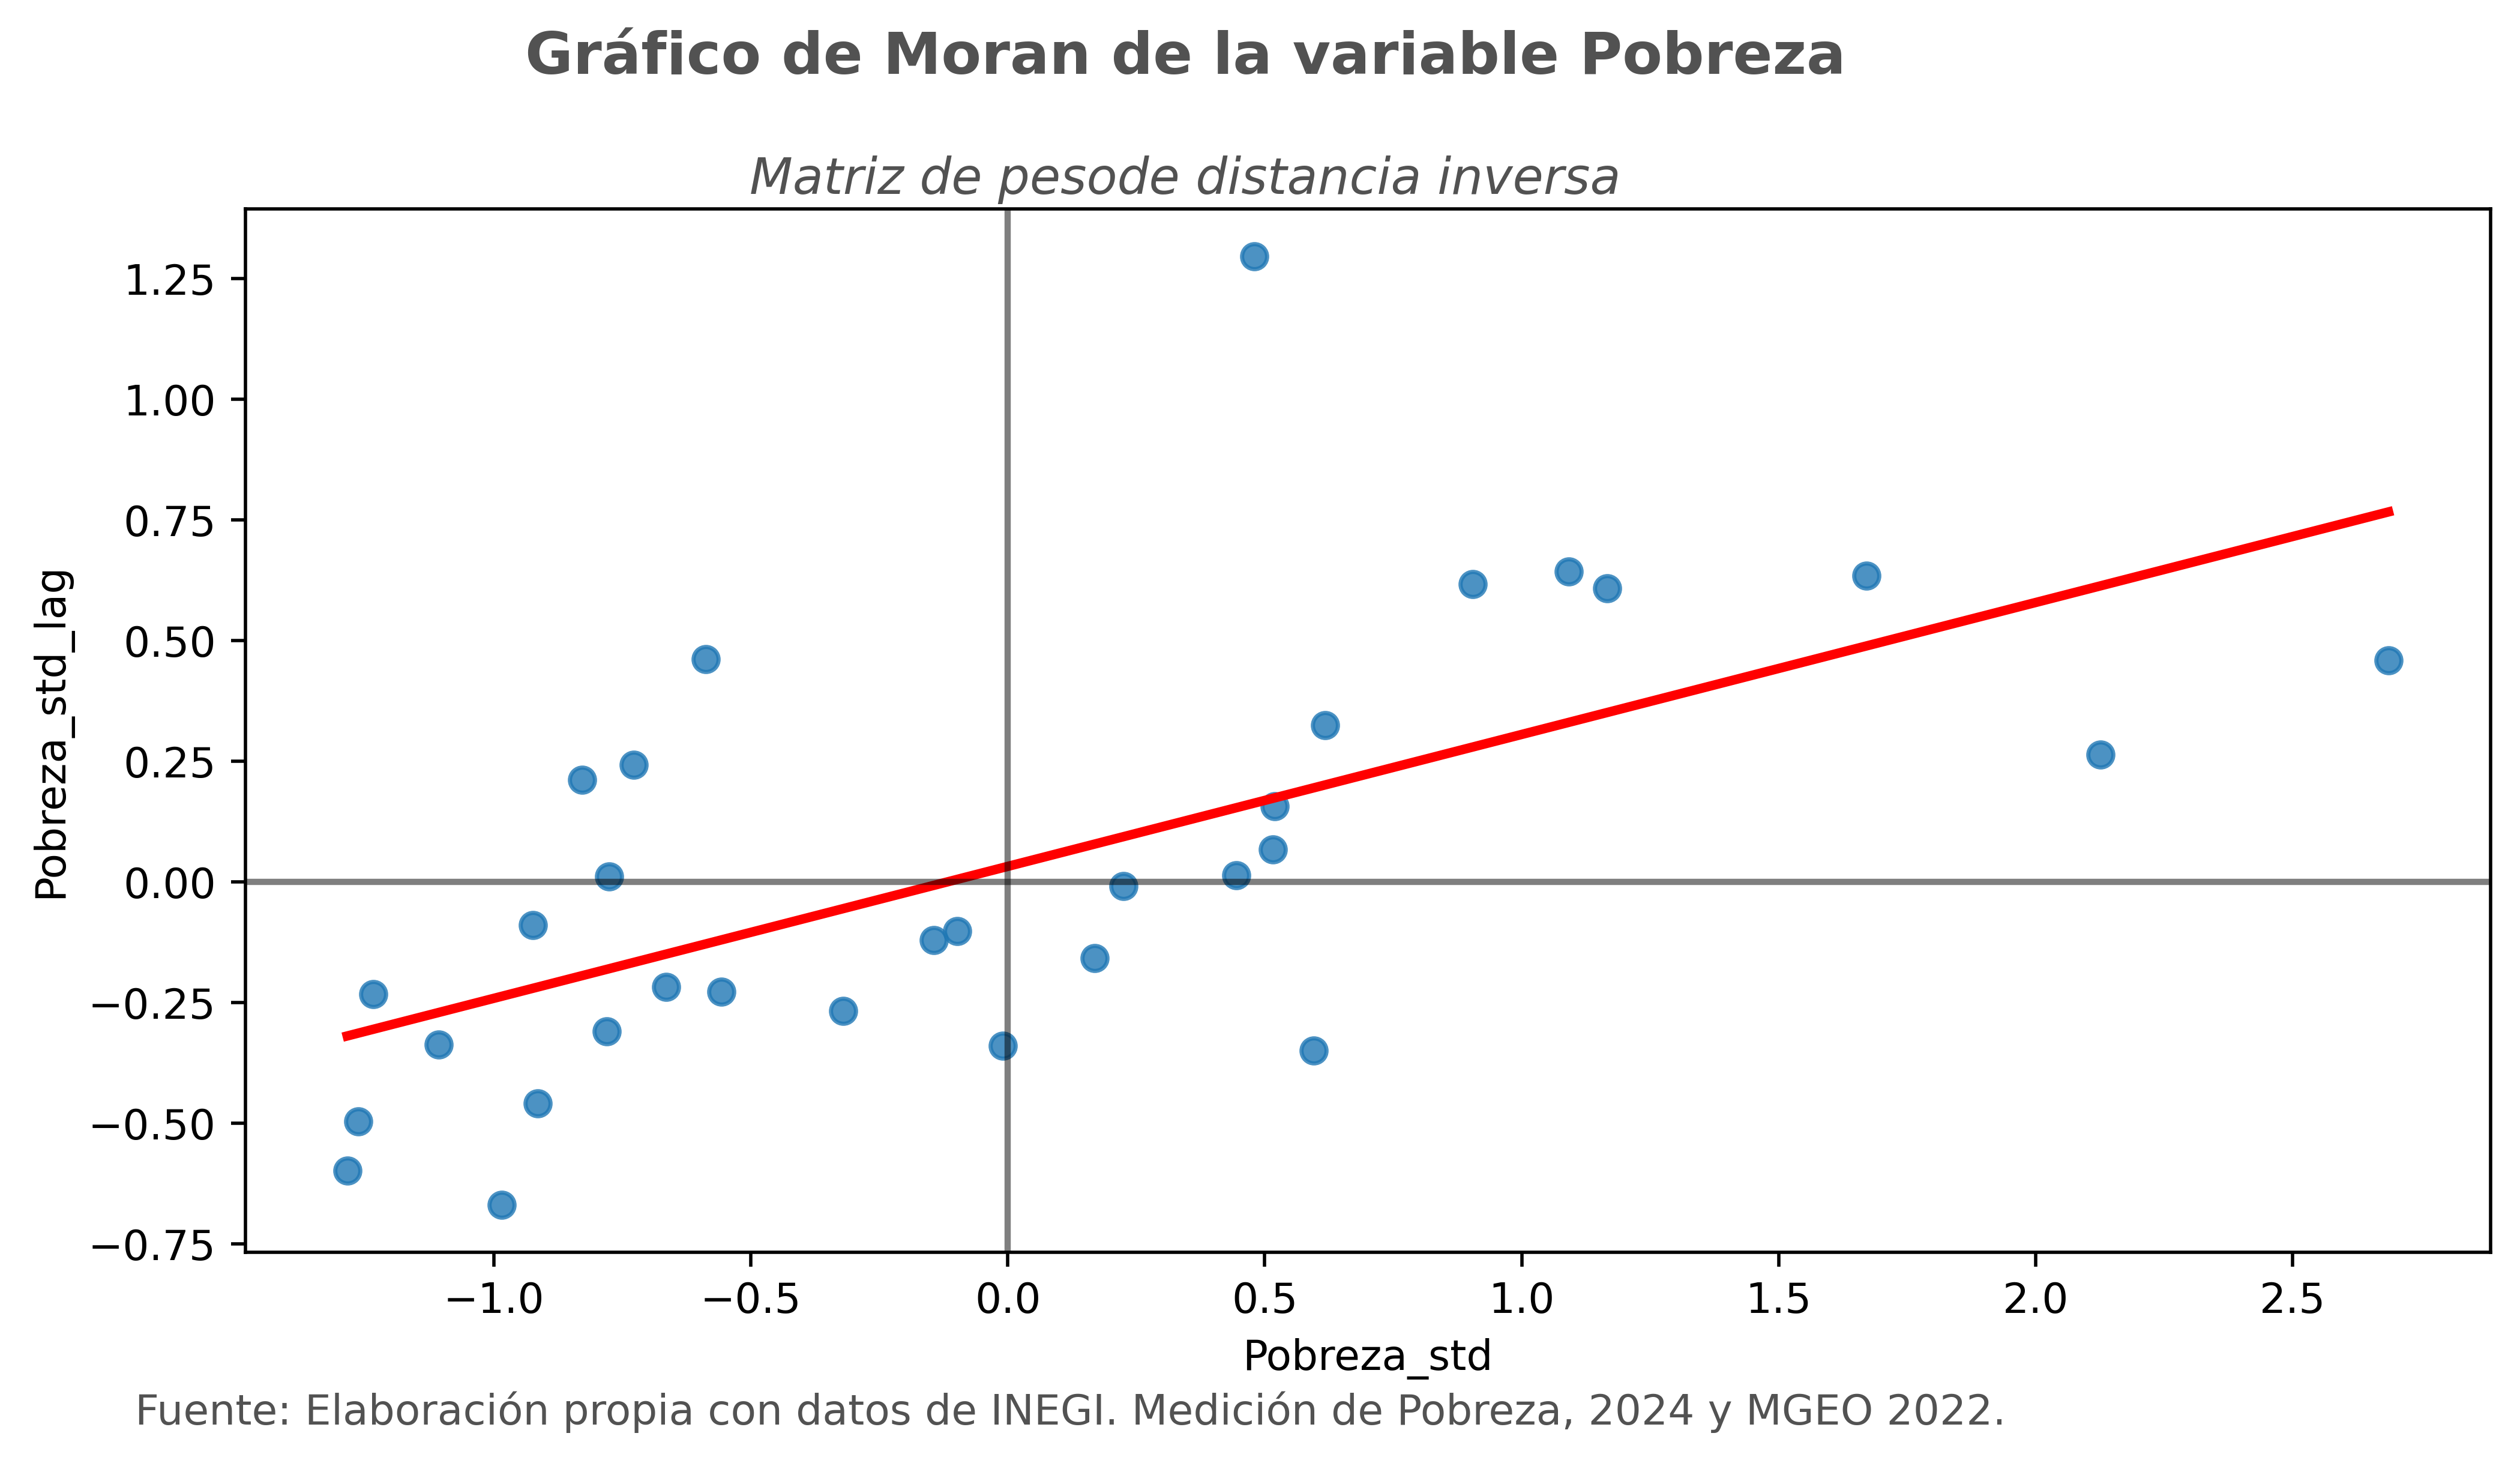

In [26]:
# Gráfico

Mapa['Pobreza_std'] = (Mapa['Pobreza']-Mapa['Pobreza'].mean())/np.std(Mapa['Pobreza'])
Mapa['Pobreza_std_lag'] = weights.spatial_lag.lag_spatial(W_D_inv, Mapa['Pobreza_std'])

f, ax = plt.subplots(1, figsize = (10,5), dpi = 500)
sns.regplot(
    x = 'Pobreza_std',
    y = 'Pobreza_std_lag',
    ci = None,
    data = Mapa,
    line_kws = {'color': 'r'}
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
plt.figtext(0.4, 0.95, "Gráfico de Moran de la variable Pobreza",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Matriz de pesode distancia inversa",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos de INEGI. Medición de Pobreza, 2024 y MGEO 2022.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.89])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Moran_Dist_inv.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')

## Estadístico global de Geary

In [27]:
# Cálculo del estadístico de Geary

geary = esda.geary.Geary(Mapa['Pobreza'], W_queen)

In [28]:
print(f"El valor del índice es: {geary.C:.3f}\nEl valor del estadístico Z es: {geary.z_norm:.3f}\nLa probabilidad del estadístico z es de: {geary.p_norm:.3f}")

El valor del índice es: 0.411
El valor del estadístico Z es: -4.457
La probabilidad del estadístico z es de: 0.000


Ejercicio: Replicar el procedimiento utilizando los diferentes tipos de matriz de peso espacial y comparar los resultados inferenciales sobre la autocorrelación espacial.

# Autocorrelación espacial local
## Estadístico de moran local

In [48]:
# Cálculo del estadístico de moran local

np.random.seed(123)

lmoran = esda.moran.Moran_Local(Mapa['Pobreza'], W_queen)

In [49]:
df_moran_local = pd.DataFrame(
    {
        'Poligono': Mapa['CVE_ENT'],
        "Moran_I": lmoran.Is,
        "Z_value": lmoran.z_sim,
        "P_value": lmoran.p_z_sim
    }
)

df_moran_local

,Poligono,Moran_I,Z_value,P_value
0,1,0.026378,0.094700,0.462277
1,2,1.400412,1.660812,0.048376
2,3,1.574362,1.352194,0.088157
3,4,-0.068987,-0.154618,0.438561
4,5,0.419742,0.851282,0.197306
5,6,0.098870,0.199670,0.420869
6,7,2.877333,2.349925,0.009389
7,8,0.638458,1.521807,0.064029
8,9,-0.211646,-0.488056,0.312755
9,10,0.004913,1.165158,0.121978


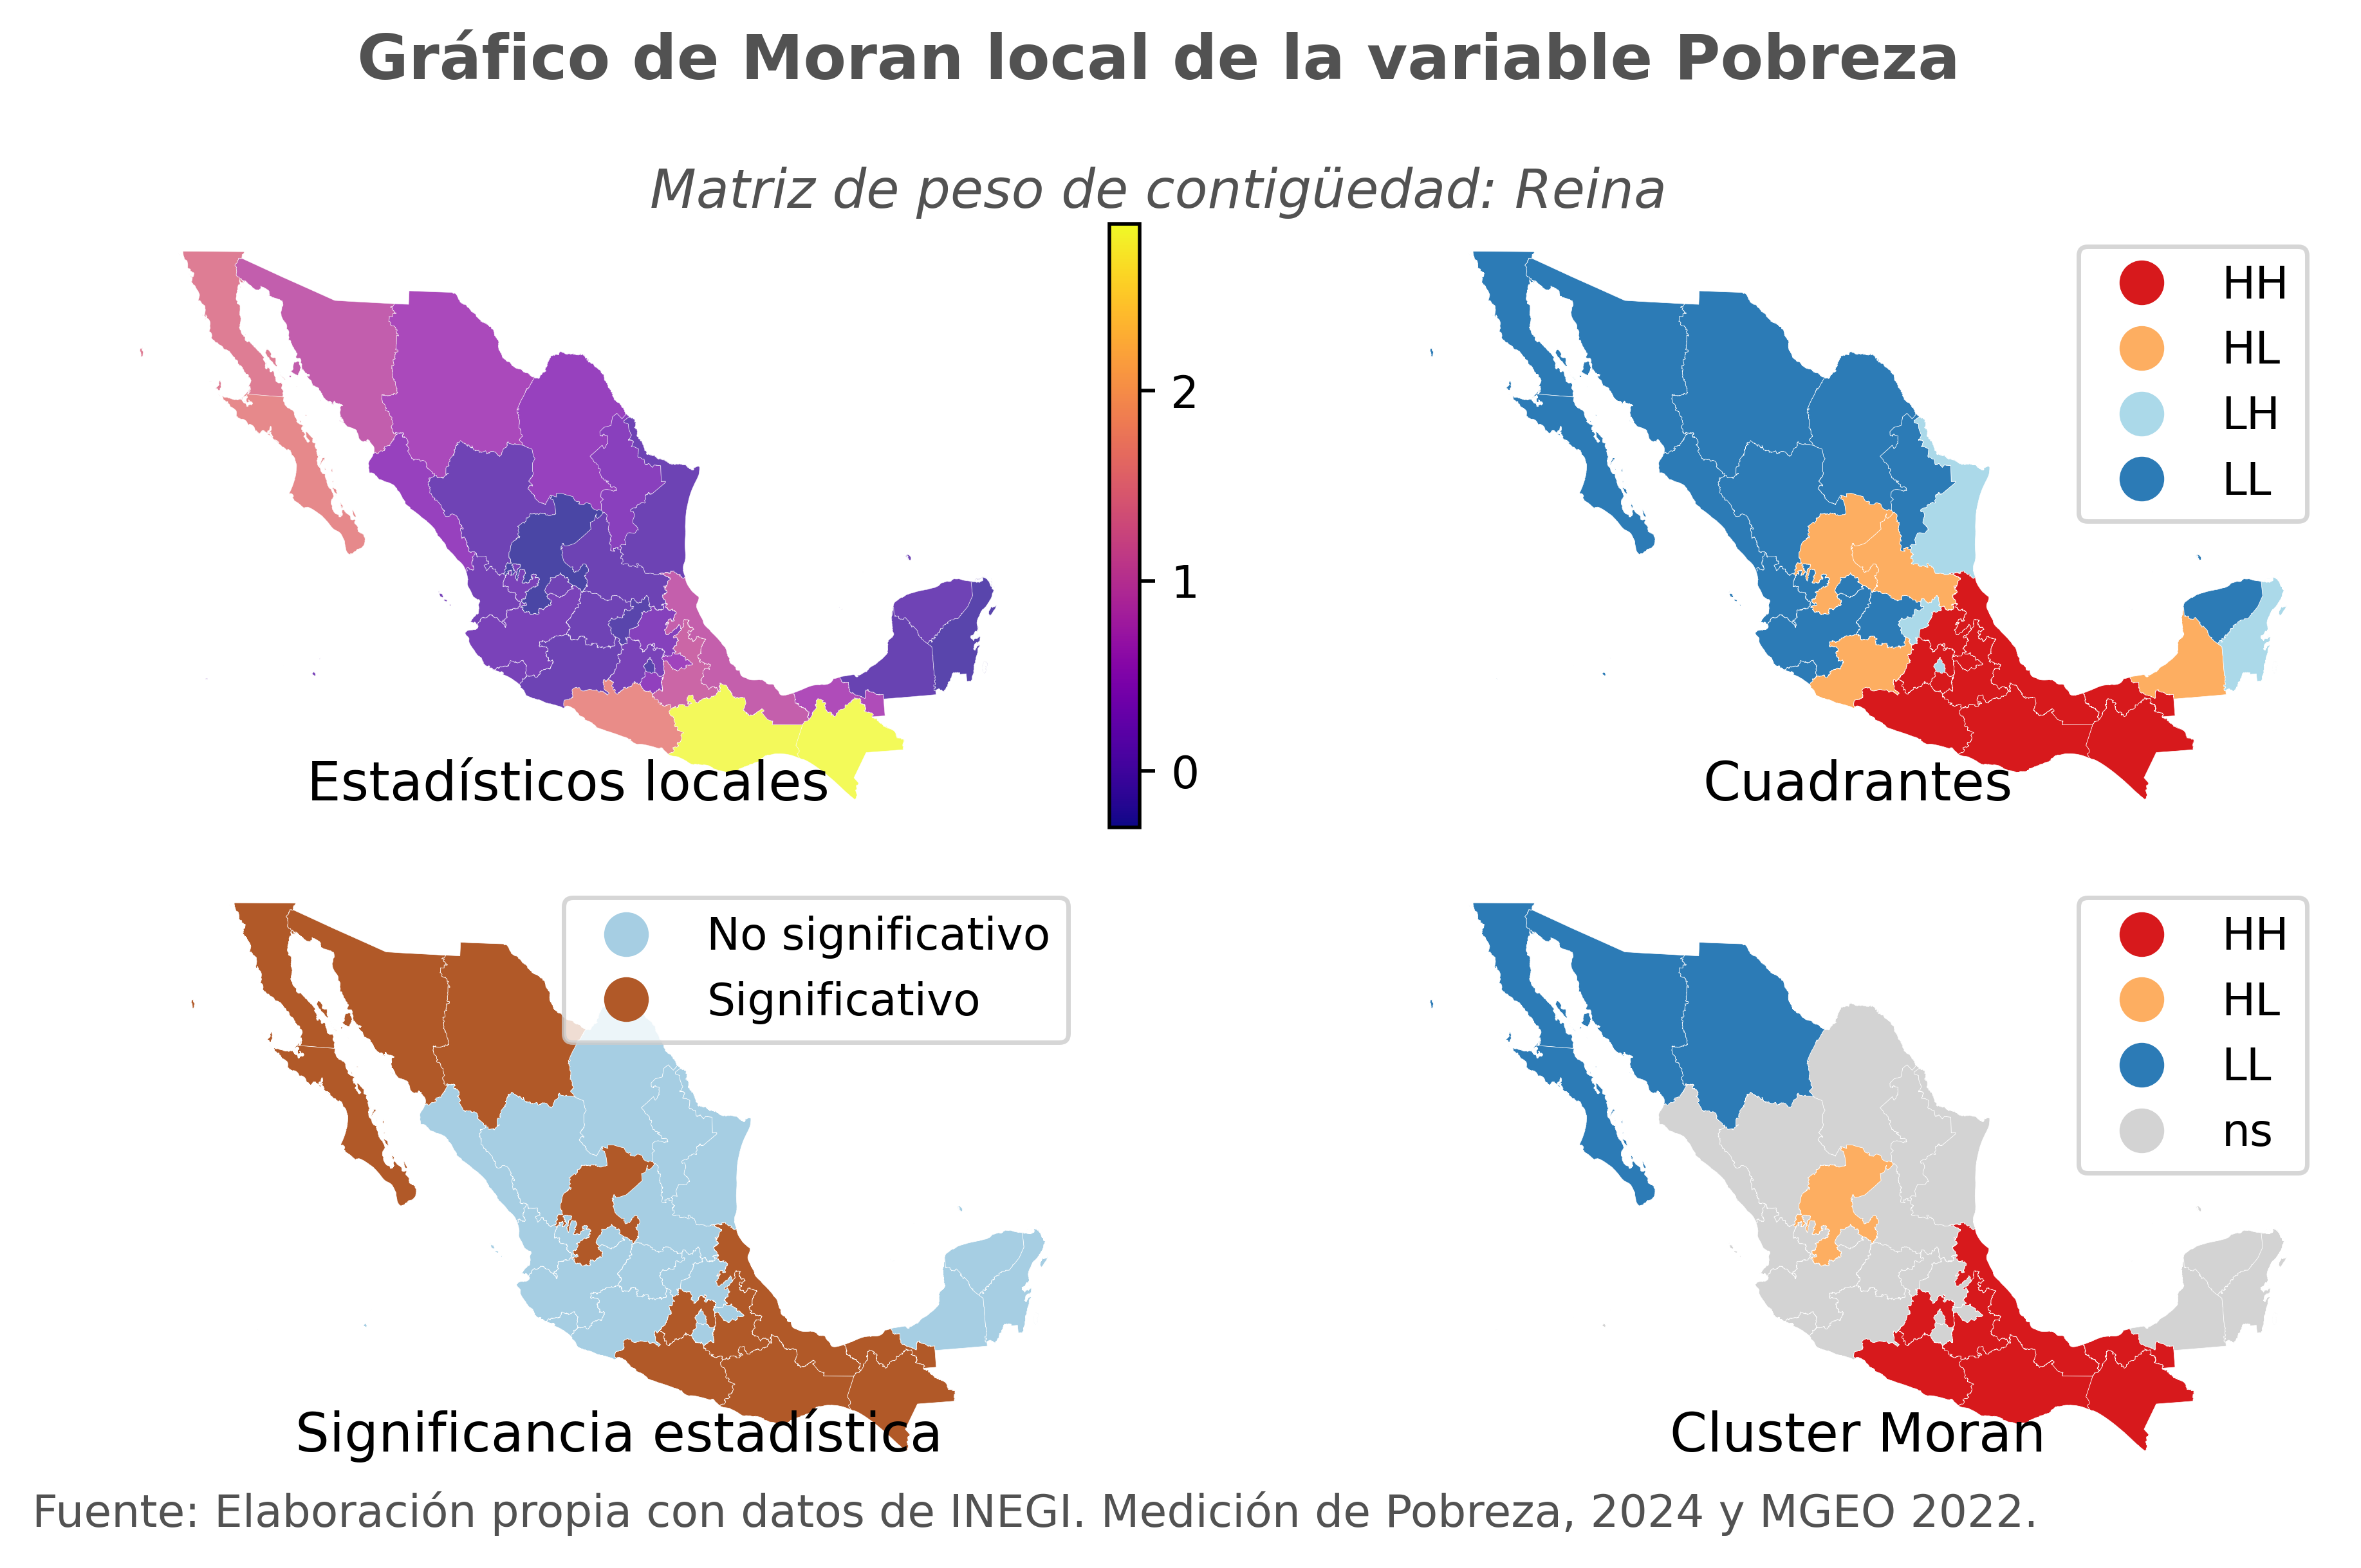

In [50]:
# Mapa que permite identificación de I. Moran local con significancia estadística

f, axs = plt.subplots(nrows = 2, ncols =2, figsize = (10,5), dpi = 500)
axs = axs.flatten()

# Mapa coloreado del estadístico de Moran Local

ax = axs[0]
Mapa.assign(
    Is = lmoran.Is
).plot(
    column = "Is",
    cmap = "plasma",
    k = 5,
    edgecolor = "white",
    linewidth = 0.1,
    alpha = 0.75,
    legend = True,
    ax = ax
)

# Cuadrantes

ax = axs[1]

esdaplot.lisa_cluster(lmoran, Mapa, p=1, ax = ax)

# Mapa de significancia

ax = axs[2]
labels = pd.Series(
    1 * (lmoran.p_sim < 0.05),
    index = Mapa.index
).map({1: "Significativo", 0:"No significativo"})

Mapa.assign(
    cl = labels
).plot(
    column = "cl",
    categorical = True,
    k = 2,
    cmap = "Paired",
    linewidth = 0.1,
    edgecolor = "white",
    legend = True,
    ax = ax
)

# Mapa de cluster

ax = axs[3]
esdaplot.lisa_cluster(lmoran, Mapa, p = 0.05, ax = ax)

for i, ax in enumerate(axs.flatten()):
  ax.set_axis_off()
  ax.set_title(
      [
          "Estadísticos locales",
          "Cuadrantes",
          "Significancia estadística",
          "Cluster Moran"
      ][i],
      y = 0
  )
plt.figtext(0.4, 0.95, "Gráfico de Moran local de la variable Pobreza",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Matriz de peso de contigüedad: Reina",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos de INEGI. Medición de Pobreza, 2024 y MGEO 2022.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.89])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Moran_Local_pobreza.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')


## Estadístico de Geary Local

In [62]:
# Cálculo de Geary Local

np.random.seed(123)

lgeary = esda.Geary_Local(W_queen).fit(Mapa['Pobreza'])

In [65]:
df_geary_local = pd.DataFrame(
    {
        'Poligono': Mapa['CVE_ENT'],
        "Geary_L": lgeary.localG,
        "P_value": lgeary.p_sim
    }
)

df_geary_local

,Poligono,Geary_L,P_value
0,1,0.945546,0.495
1,2,0.045338,0.008
2,3,0.000441,0.001
3,4,0.780487,0.190
4,5,1.039377,0.244
5,6,0.969280,0.377
6,7,2.737352,0.014
7,8,0.219470,0.039
8,9,0.942168,0.411
9,10,0.615743,0.297


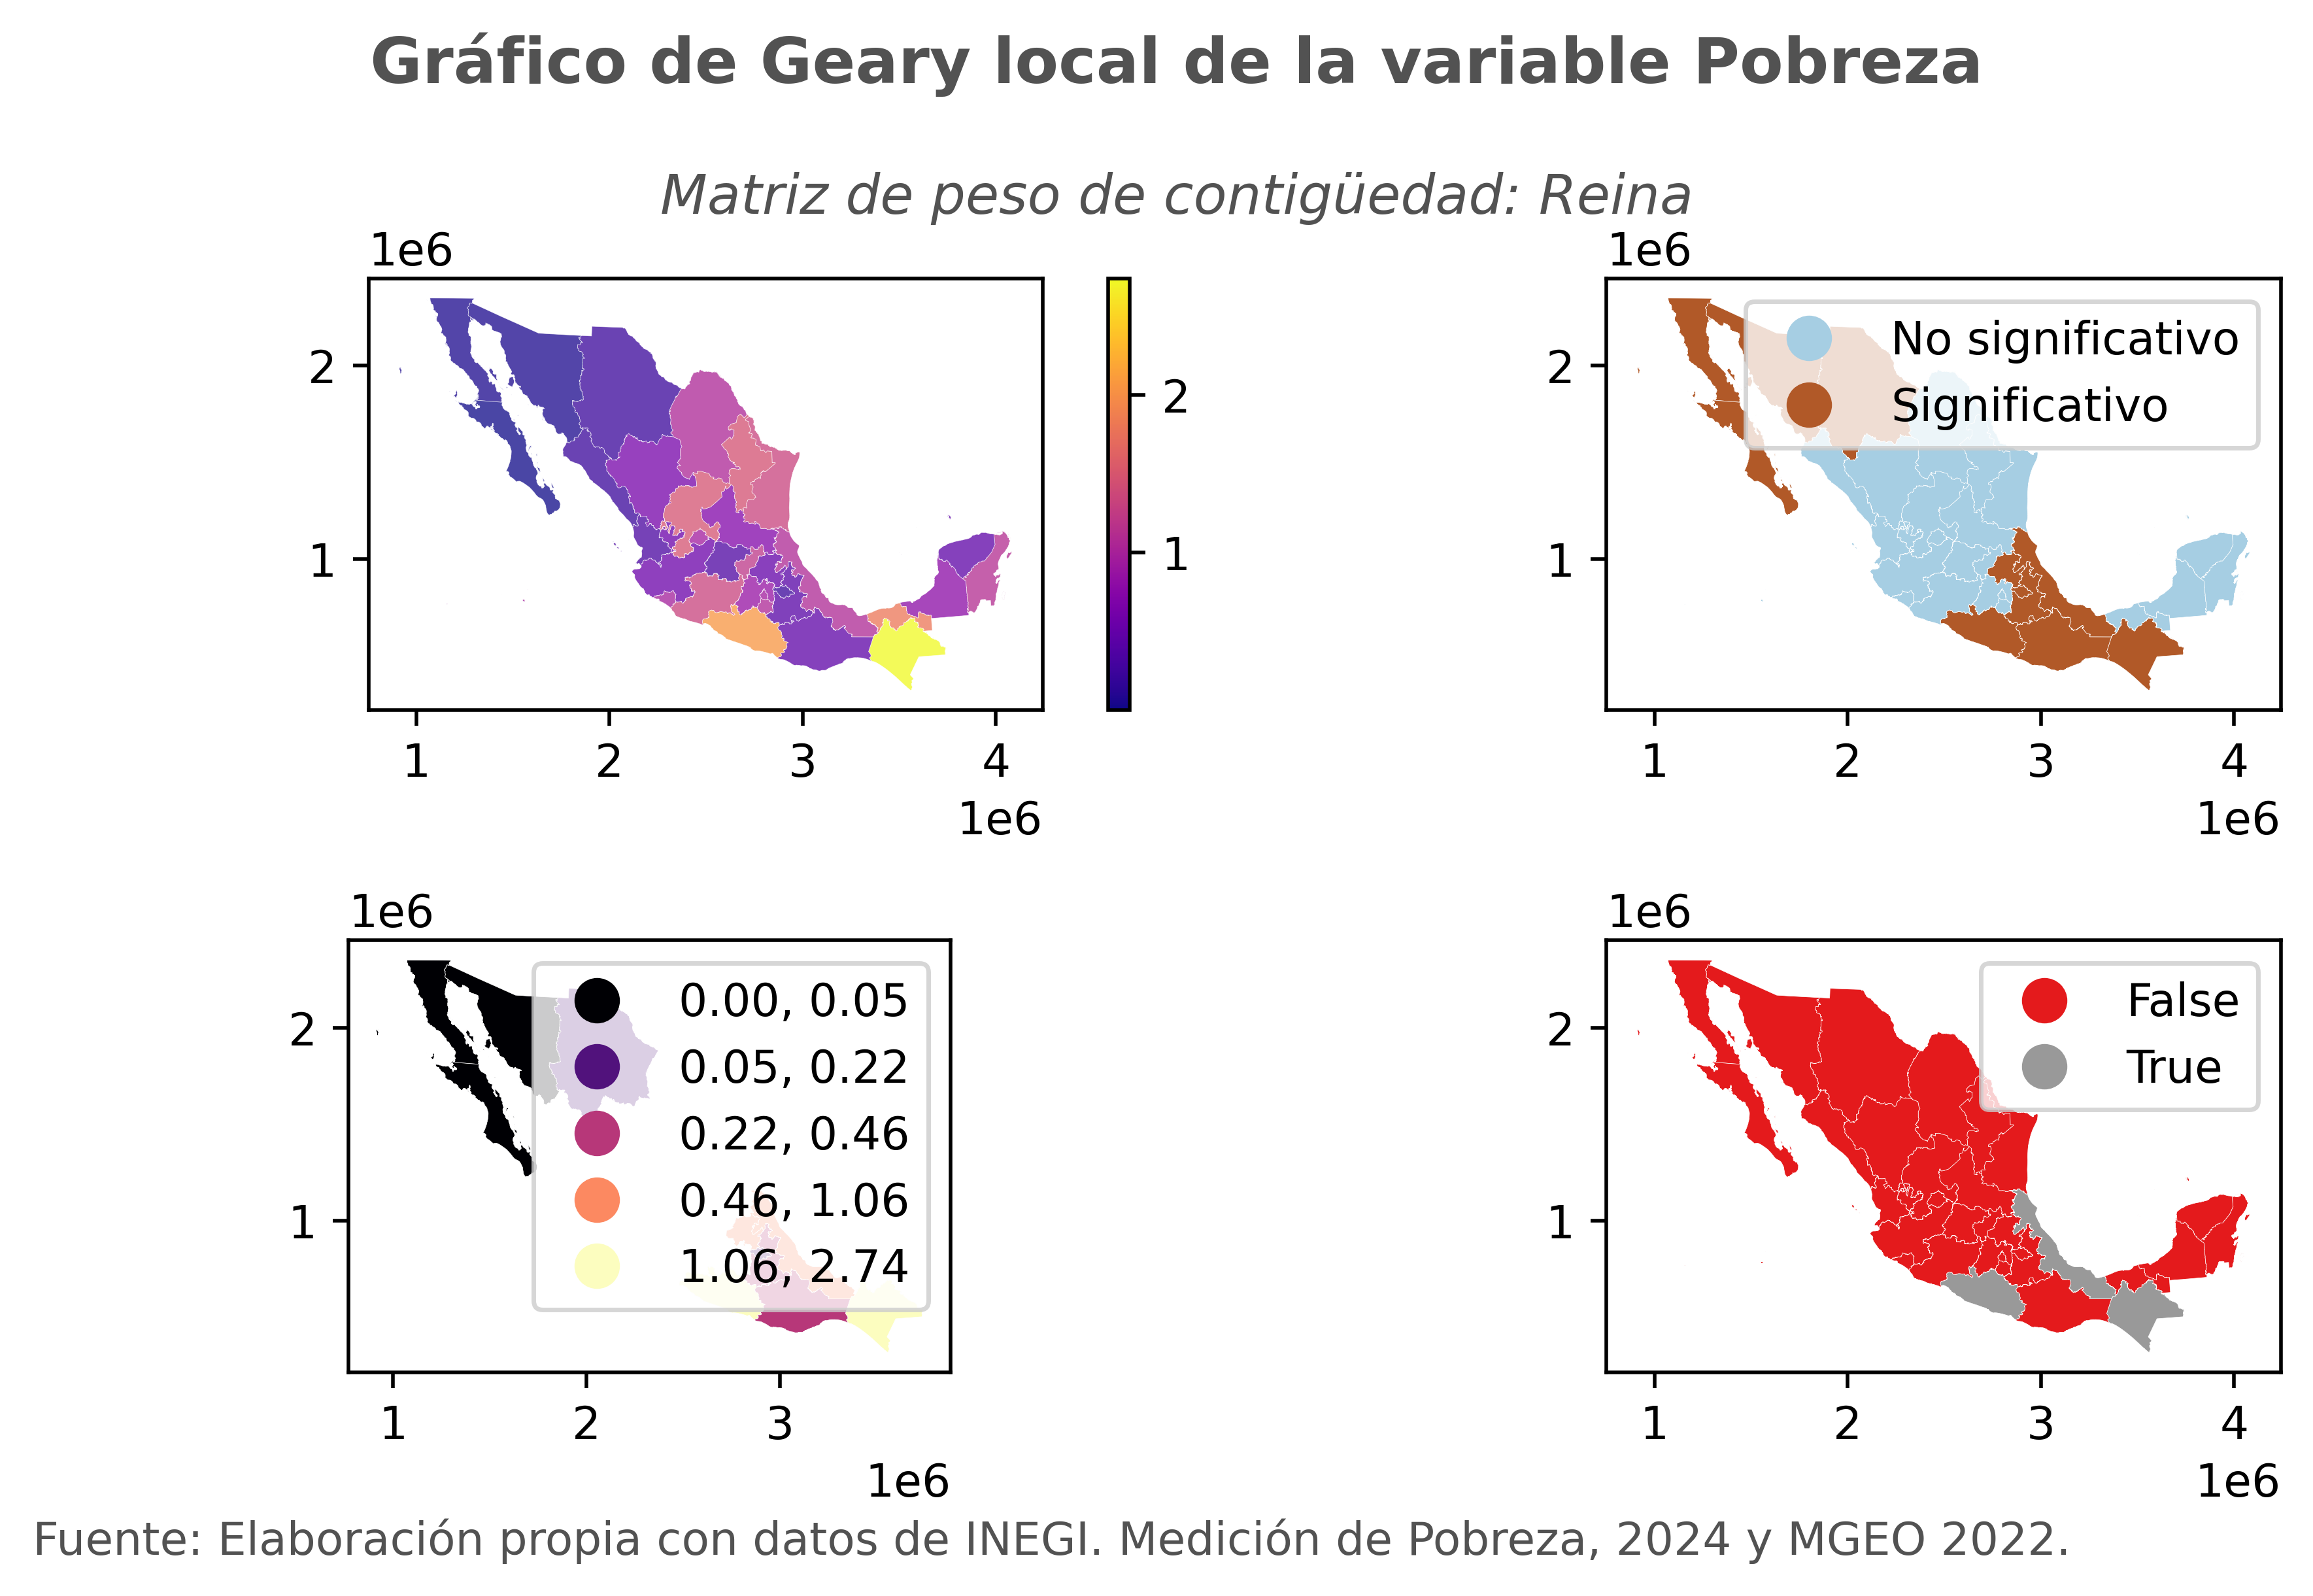

In [68]:
# Mapa que permite identificación de I. Moran local con significancia estadística

f, axs = plt.subplots(nrows = 2, ncols =2, figsize = (10,5), dpi = 500)
axs = axs.flatten()

# Mapa coloreado del estadístico de Moran Local

ax = axs[0]
Mapa.assign(
    Geary = lgeary.localG
).plot(
    column = "Geary",
    cmap = "plasma",
    k = 5,
    edgecolor = "white",
    linewidth = 0.1,
    alpha = 0.75,
    legend = True,
    ax = ax
)

# Mapa de significancia

ax = axs[1]
labels = pd.Series(
    1 * (lgeary.p_sim < 0.05),
    index = Mapa.index
).map({1: "Significativo", 0:"No significativo"})

Mapa.assign(
    cl = labels
).plot(
    column = "cl",
    categorical = True,
    k = 2,
    cmap = "Paired",
    linewidth = 0.1,
    edgecolor = "white",
    legend = True,
    ax = ax
)

# Local significativo filtrado

ax = axs[2]

Mapa.assign(
    Geary_sig = np.where(
        lgeary.p_sim<0.05,
        lgeary.localG,
        np.nan
    )
).plot(
    column="Geary_sig",
    cmap="magma",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    legend=True,
    ax=ax
)


# Zonas de altaa disimilitud

ax = axs[3]

Mapa.assign(
    Disimilitud = (lgeary.localG > 1) & (lgeary.p_sim < 0.05)
).plot(
    column="Disimilitud",
    categorical=True,
    cmap="Set1",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

plt.figtext(0.4, 0.95, "Gráfico de Geary local de la variable Pobreza",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Matriz de peso de contigüedad: Reina",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos de INEGI. Medición de Pobreza, 2024 y MGEO 2022.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.89])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Geary_Local_pobreza.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')
